# **Análise Exploratória de Dados**

### **Contexto do Projeto**

- O conjunto fornecido pela a empresa AWS foi um banco de dados de grandes marketplaces digitais, sendo o nosso principal desafio será investigar os dados de avaliações de clientes, buscando compreender a relação entre os comentários textuais e as notas atribuídas, identificando padrões,
tendências e possíveis inconsistências na percepção de satisfação.

### **Problema**

- Em marketplaces digitais, clientes avaliam produtos por meio de notas (1 a 5) e comentários textuais.
Mas, nem sempre a nota atribuída é semelhante com o conteúdo do comentário, o que pode dificultar
a interpretação real da satisfação do cliente.
Diante disso, surge a necessidade de analisar a relação entre as avaliações numéricas e os comentários,
buscando identificar padrões de comportamento e possíveis inconsistências.

### **Objetivo**

- Realizar uma análise exploratória dos dados a fim de investigar a relação entre as notas atribuídas e o
conteúdo textual dos comentários dos clientes.
O Desafio Técnico: identificar padrões, tendências e possíveis incoerências entre a nota e o comentário, utilizando técnicas de análise exploratória de dados e interpretação textual básica.

## **Informações do conjunto de dados:**

- Possuimos 9 Tabelas incluindo uma auxiliar, sendo elas:
    - Tabelas avaliacoes
    - Tabela pedidos
    - Tabela itens_pedido
    - Tabela pagamentos
    - Tabela clientes
    - Tabela vendedores
    - Tabela produtos
    - Tabela geolocalizacao

**Sendo a principal, a Tabela avaliacoes pois iremos ultiliza-lá para realizar a análise exploratória**

## **Importação das bibliotecas**

- Aqui importamos as bibliotecas essenciais para manipulação, análise e visualização dos dados, como
Pandas, Numpy, Matplotlib, Seaborn e Warnings.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')

## **Carregando o conjunto de dados**

Aqui carregamos as tabelas, cada uma com seus respectivos data frames:
| DataFrame | Tabela Representada |
| :--- | :--- |
| `df_avaliacoes` | Avaliações |
| `df_pedidos` | Pedidos |
| `df_itens_pedidos` | Itens do Pedido |
| `df_pagamentos` | Pagamentos |
| `df_clientes` | Clientes |
| `df_vendedores` | Vendedores |
| `df_produtos` | Produtos |
| `df_geolocalizacao` | Geolocalização |
| `df_auxilar` | Auxiliar |

In [2]:
df_avaliacoes = pd.read_csv('../data/raw/avaliacoes.csv')
df_clientes = pd.read_csv('../data/raw/clientes.csv')
df_geolocalizacao = pd.read_csv('../data/raw/geolocalizacao.csv')
df_itens_pedidos = pd.read_csv('../data/raw/itens_pedidos.csv')
df_pagamentos = pd.read_csv('../data/raw/pagamentos.csv')
df_pedidos = pd.read_csv('../data/raw/pedidos.csv')
df_produtos = pd.read_csv('../data/raw/produtos.csv')
df_tabela_auxiliar = pd.read_csv('../data/raw/tabela_auxiliar.csv')
df_vendedores = pd.read_csv('../data/raw/vendedores.csv')

## Entendendo o conjunto de dados

In [3]:
def resumo_tabelas(tabelas):
    for nome, tabela in tabelas.items():
        linhas, colunas = tabela.shape
        nulos = tabela.isnull().sum()
        nulos_total = nulos.sum()
        duplicatas = tabela.duplicated().sum()

        print(f'\n{"="*150}')
        print(f'  TABELA: {nome.upper()}')
        print(f'{"="*150}')
        print(f'  Linhas      : {linhas}')
        print(f'  Colunas     : {colunas}')
        print(f'  Nulos       : {nulos_total} ({round(nulos_total / (linhas * colunas) * 100, 1)}% do total)')
        print(f'  Duplicatas  : {duplicatas} ({round(duplicatas / linhas * 100, 1)}% das linhas)')

    
        if nulos_total > 0:
            print(f'\n  Nulos por coluna:')
            for col, qtd in nulos[nulos > 0].items():
                print(f'    • {col}: {qtd} ({round(qtd / linhas * 100, 1)}%)')
    
        print(f'  Colunas     : {list(tabela.columns)}')
    
        print(f'\n  Primeiras 5 linhas:')
        display(tabela.head(5))
        print(f'  Últimas 5 linhas:')
        display(tabela.tail(5))
        print(f'  5 linhas aleatórias:')
        display(tabela.sample(5))
        print(f'  Tipos de dados:')
        display(tabela.dtypes)
        print(f'  Memória utilizada por coluna:')
        display(tabela.memory_usage(deep=True))
        print()

In [4]:
tabelas = {
    'df_avaliacoes': df_avaliacoes,
    'df_clientes': df_clientes,
    'df_geolocalizacao': df_geolocalizacao,
    'df_itens_pedidos': df_itens_pedidos,
    'df_pagamentos': df_pagamentos,
    'df_pedidos': df_pedidos,
    'df_produtos': df_produtos,
    'df_tabela_auxiliar': df_tabela_auxiliar,
    'df_vendedores': df_vendedores
}

resumo_tabelas(tabelas)


  TABELA: DF_AVALIACOES
  Linhas      : 99224
  Colunas     : 7
  Nulos       : 145903 (21.0% do total)
  Duplicatas  : 0 (0.0% das linhas)

  Nulos por coluna:
    • review_comment_title: 87656 (88.3%)
    • review_comment_message: 58247 (58.7%)
  Colunas     : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

  Primeiras 5 linhas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


  Últimas 5 linhas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13
99223,efe49f1d6f951dd88b51e6ccd4cc548f,90531360ecb1eec2a1fbb265a0db0508,1,NaN,"meu produto chegou e ja tenho que devolver, po...",2017-07-03 00:00:00,2017-07-03 21:01:49


  5 linhas aleatórias:


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
2593,5a4236931428800e9d9cc04af0987118,2916,sao paulo,SP
470,259f7b5e6e482c230e5bfaa670b6bb8f,8550,poa,SP
2043,113e3a788b935f48aad63e1c41dac1bd,12570,aparecida,SP
3060,21e83881401b92b49fb09a16d3852291,38405,uberlandia,MG
1512,b3f19518fcec265b2e97af287725f981,15170,tanabi,SP


  Tipos de dados:


seller_id                   str
seller_zip_code_prefix    int64
seller_city                 str
seller_state                str
dtype: object

  Memória utilizada por coluna:


Index                        132
seller_id                 123800
seller_zip_code_prefix     24760
seller_city                56230
seller_state               30950
dtype: int64

## **Tratamento dos tipos de dados**

- Nesta etapa, realizamos a padronização e otimização dos tipos de dados das tabelas, convertendo cada coluna para o formato mais adequado de acordo com sua natureza. Colunas de identificação foram convertidas para o tipo string, variáveis categóricas para category, valores numéricos para tipos inteiros e decimais mais eficientes (Int8, Int16, Int32, Int64 e float32) e colunas de data e hora para o formato datetime.

- Esse processo teve como objetivo garantir maior consistência dos dados, reduzir o consumo de memória e melhorar o desempenho das operações de manipulação e análise, além de facilitar a realização de consultas, cálculos e análises temporais ao longo do projeto.

In [5]:
df_avaliacoes = df_avaliacoes.astype({
    'review_id':'string',
    'order_id':'string',
    'review_score':'Int8',
    'review_comment_title':'string',
    'review_comment_message':'string',
})
for col in ['review_creation_date', 'review_answer_timestamp']:
    df_avaliacoes[col] = pd.to_datetime(df_avaliacoes[col])

df_clientes = df_clientes.astype({
    'customer_id':'string',
    'customer_unique_id':'string',
    'customer_zip_code_prefix':'string',
    'customer_city':'category',
    'customer_state':'category',
})


df_geolocalizacao = df_geolocalizacao.astype({
    'geolocation_zip_code_prefix':'string',
    'geolocation_lat':'float32',
    'geolocation_lng':'float32',
    'geolocation_city':'category',
    'geolocation_state':'category',
})

df_itens_pedidos = df_itens_pedidos.astype({
    'order_id':'string',
    'order_item_id':'Int64',
    'product_id':'string',
    'seller_id':'string',
    'price':'float32',
    'freight_value':'float32',
})
df_itens_pedidos['shipping_limit_date'] = pd.to_datetime(df_itens_pedidos['shipping_limit_date'])

df_pagamentos = df_pagamentos.astype({
    'order_id':'string',
    'payment_sequential':'Int8',
    'payment_type':'category',
    'payment_installments':'Int8',
    'payment_value':'float32',
})

df_pedidos = df_pedidos.astype({
    'order_id':'string',
    'customer_id':'string',
    'order_status':'category',
})
for col in [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]:
    df_pedidos[col] = pd.to_datetime(df_pedidos[col])

df_produtos = df_produtos.astype({
    'product_id':'string',
    'product_category_name':'category',
    'product_name_lenght':'Int16',
    'product_description_lenght':'Int32',
    'product_photos_qty':'Int8',
    'product_weight_g':'float32',
    'product_length_cm':'float32',
    'product_height_cm':'float32',
    'product_width_cm':'float32',
})

df_tabela_auxiliar = df_tabela_auxiliar.astype({
    'product_category_name':'category',
    'product_category_name_english':'category',
})

df_vendedores = df_vendedores.astype({
    'seller_id':'string',
    'seller_zip_code_prefix':'string',
    'seller_city':'category',
    'seller_state':'category',
})

## **Tabela de avaliações**

- Como o objetivo deste projeto é compreender a relação entre as notas atribuídas pelos clientes e os comentários registrados nas avaliações, realizamos uma análise mais detalhada da tabela de avaliações.Nesta etapa, apresentamos uma visão geral da tabela, incluindo a quantidade de linhas e colunas, o total de valores nulos e registros duplicados, além da identificação das colunas com dados ausentes. Essa análise inicial permite avaliar a qualidade dos dados e identificar possíveis limitações que poderão impactar as análises posteriores.

 *Observa-se que a tabela possui 99.224 registros e 7 colunas, sem ocorrências de duplicatas. No entanto, há uma quantidade significativa de valores nulos nas colunas de título e mensagem das avaliações, indicando que muitos clientes atribuíram notas sem registrar comentários textuais.*

In [6]:
tabelas = {
    'df_avaliacoes': df_avaliacoes,
}

resumo_tabelas(tabelas)


  TABELA: DF_AVALIACOES
  Linhas      : 99224
  Colunas     : 7
  Nulos       : 145903 (21.0% do total)
  Duplicatas  : 0 (0.0% das linhas)

  Nulos por coluna:
    • review_comment_title: 87656 (88.3%)
    • review_comment_message: 58247 (58.7%)
  Colunas     : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

  Primeiras 5 linhas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,<NA>,<NA>,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,<NA>,<NA>,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,<NA>,<NA>,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,<NA>,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,<NA>,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


  Últimas 5 linhas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,<NA>,<NA>,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,<NA>,<NA>,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,<NA>,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,<NA>,<NA>,2018-07-01,2018-07-02 12:59:13
99223,efe49f1d6f951dd88b51e6ccd4cc548f,90531360ecb1eec2a1fbb265a0db0508,1,<NA>,"meu produto chegou e ja tenho que devolver, po...",2017-07-03,2017-07-03 21:01:49


  5 linhas aleatórias:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
54960,275e448de12210e46132a1d63b8f8fc6,3461745647fb12cf7450b0ca1df45286,5,<NA>,Muito bom comprar por lannister,2017-12-20,2017-12-23 00:41:37
38744,34132f2aa3091109b8ed87ae97f2a14f,774948f6702fc1d316b81f28fea3de9b,5,Recomendo,"Vendedor correto, produto entregue com agilidade.",2018-06-15,2018-06-18 15:26:14
95166,2801110c607a4ccb0acb11c27eb155c1,d21bdc8a5aec774d419d8db5455e0ae8,5,<NA>,<NA>,2018-03-09,2018-03-12 03:21:25
41700,359f7a1ad668efd4e7a310f6c0575e9e,4c53c2b42c60815a6be4e7bc09cb0b59,5,<NA>,<NA>,2017-05-18,2017-05-19 14:07:33
95764,05c1a1a0050664a53d7d67b59e896a4d,cc7a01248e3779979631ce8dea5c8292,1,<NA>,stark não é mais a mesma loja que era. Até o m...,2018-03-23,2018-03-25 03:46:21


  Tipos de dados:


review_id                          string
order_id                           string
review_score                         Int8
review_comment_title               string
review_comment_message             string
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

  Memória utilizada por coluna:


Index                          132
review_id                  3968960
order_id                   3968960
review_score                198448
review_comment_title        947467
review_comment_message     3671710
review_creation_date        793792
review_answer_timestamp     793792
dtype: int64

## **Unindo as variáveis `review_comment_title` e `review_comment_message`**

- Para facilitar a análise textual das avaliações, as colunas review_comment_title e review_comment_message foram combinadas em uma única variável chamada review_comment.

- Durante o processo, os valores nulos foram substituídos por strings vazias utilizando fillna(''), evitando erros na concatenação e preservando os comentários disponíveis.

In [7]:
# unindo as variáveis `review_comment_title` e `review_comment_message` em uma nova coluna `review_comment_full`
df_avaliacoes['review_comment'] = df_avaliacoes['review_comment_title'].fillna('') + ' ' + df_avaliacoes['review_comment_message'].fillna('')

In [8]:
df_avaliacoes.sample(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_comment
85612,6e997c2b446c1beed78512667fd37e02,8809eb241de20bada1a2eedfa3c47504,5,<NA>,O carrinho OHlalà da chicco é simplesmente mar...,2017-10-28,2017-10-28 14:31:19,O carrinho OHlalà da chicco é simplesmente ma...
74399,43051d774f7f0ca6e8f0159fd57e84c0,d7a02af9805cff844c09f3fcf61a73b2,4,<NA>,<NA>,2018-02-06,2018-02-10 12:43:13,
29656,e149dcf1404ee48d59a405c347347b9a,f9e3402be5a5ea63344347582ca9f45f,5,<NA>,<NA>,2017-06-21,2017-06-24 13:53:53,
23333,c25139722830fd802989a68fd0ffdfc7,fa70e6eb878dec546f11aba9afcf1f28,5,<NA>,<NA>,2017-08-30,2017-08-31 12:31:48,
40632,fd0e6c141e3e72b108a282747cfdb671,ed6104a0027e6a269ce0269f21c67f0c,4,<NA>,Pensei q os produtos q pedi fossem com mais qu...,2017-08-05,2017-08-06 02:26:54,Pensei q os produtos q pedi fossem com mais q...
87871,4f3650278a96ae7bc5ca30316a2e2fc3,11177b43d0995dfa2114ceefa2c0cc16,1,<NA>,nao entregou produto no prazo,2017-12-16,2017-12-19 12:41:33,nao entregou produto no prazo
16483,cdcdbc90c94af015c27938b8bcf348c5,263c5916eca59eff23f65a1cab611380,5,<NA>,<NA>,2018-03-30,2018-03-30 16:30:24,
70861,cf3fcabff34b05cf4edb8e4c550056b4,f23bef5ff346873476747ab073a43877,3,<NA>,<NA>,2017-06-02,2017-06-07 14:06:58,
49354,a14d4ca0e4b348d517c1516aa4a385ac,5d6343c55d971fe043e51c84df19bdd9,5,<NA>,<NA>,2018-05-20,2018-05-21 20:22:30,
83554,3ad2e58bcf5c1c11cbd5767b18c86dbe,715645f32042763c55a177d5460e0c38,4,<NA>,<NA>,2017-05-16,2017-05-19 16:32:18,


## **Removendo comentários vazios**

Nesta etapa, são removidas as avaliações que possuem o campo `review_comment` vazio.


In [9]:
df_avaliacoes_limpo = df_avaliacoes[df_avaliacoes['review_comment'] != ' ']

In [10]:
df_avaliacoes_limpo.sample(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_comment
41824,6ff033d3000cf4df9f48c7ba3a9b65e8,a027b795d174ac4c8c7fd853838b5744,1,<NA>,Tive que cancelar a compra o vendedor não cons...,2018-01-13,2018-01-31 13:27:34,Tive que cancelar a compra o vendedor não con...
79464,7673ee9a5d5fe50994b91143ad8e367d,be624b5788e2a4d4dfb9414c378c20c6,5,<NA>,Gostei muito!!!\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n,2018-03-21,2018-03-22 18:55:06,Gostei muito!!!\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n
63843,39c8041924b08244a7ac04759c986f02,a7b8a73bcc7bf3850dc9f4907c5ee6f2,5,Muito bom,Show super recomendo,2018-06-30,2018-07-02 10:10:03,Muito bom Show super recomendo
96387,5efb99c050db622b062099b1721956ba,6aa40159104472e7b1ba3ea38cc2c817,5,<NA>,"Produto muito bom. A reclinacao é pequena, mas...",2018-05-23,2018-05-24 09:41:30,"Produto muito bom. A reclinacao é pequena, ma..."
90535,de01904cf74808ba87e1df65f7882ef0,2c833074fc9fbb5d8c24ec212ce02bff,2,<NA>,Qualidade baixa para o preço.\r\n,2017-10-12,2017-10-16 18:13:40,Qualidade baixa para o preço.\r\n
56259,0a075f761f200961a1642eb3ad161dea,34eb84795617859f326a6615f0fff940,5,Loja confiável,"Tudo correu perfeitamente, e entregada antes d...",2018-07-11,2018-07-13 12:08:16,"Loja confiável Tudo correu perfeitamente, e en..."
73368,c590111a133d34762cb8f2d5a02b8f12,7f943a5cd90759046667677f4cb74b0f,5,<NA>,Recomendo a firma pois a mesma é idônea.,2018-06-06,2018-06-07 01:49:15,Recomendo a firma pois a mesma é idônea.
36796,ce7424acb7f3b8b6cbef225c90598cf1,16e59b28d489ea6bc1f2f9a7057740d4,5,super recomendo,<NA>,2018-07-05,2018-07-05 14:56:56,super recomendo
8150,7cc4603e3f9458ed268d7f86054f77df,deeed712c83b155989e7ccf569ecc9c3,5,Satisfação garantida,Farei outros pedidos,2018-06-14,2018-06-19 15:19:36,Satisfação garantida Farei outros pedidos
45044,197a3dac9318d6f23a5fb2ad23ea1efd,c23e171590482930d50c033857c85deb,4,<NA>,"ENTREGA BEM ANTES DO PRAZO, MATERIAL MUITO BOM...",2017-12-16,2017-12-18 10:42:43,"ENTREGA BEM ANTES DO PRAZO, MATERIAL MUITO BO..."


## **Removendo letras maiúsculas e pontuações**

Nesta outra etapa, são removidas as letras maiúsculas e pontuações que possuem no campo `review_comment`.


In [11]:
df_avaliacoes_limpo['review_comment'] = df_avaliacoes['review_comment'].str.lower()

In [12]:
import string

df_avaliacoes_limpo['review_comment'] = df_avaliacoes_limpo['review_comment'].str.translate(str.maketrans('', '', string.punctuation))

In [13]:
df_avaliacoes_limpo.sample(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_comment
32836,ca0161842bfb1a23616c4dd04eff951e,adeb87b732e8e3684863866c067aa9de,1,<NA>,Pedi o cancelamento e mesmo assim me entregara...,2018-08-29,2018-08-29 18:47:29,pedi o cancelamento e mesmo assim me entregar...
24585,752d6729f1d725fffda68151f3756b6b,162fcce5f7c895e5afb504f6f1cee4ed,5,relógio exercito,"excelente produto,ótima qualidade e rapidez na...",2018-06-12,2018-06-14 21:04:12,relógio exercito excelente produtoótima qualid...
32184,836e63be6505eaccdfac1c61e941d838,1bb89d713790b13c538111b4e0e8c80f,4,<NA>,muito bom,2018-02-03,2018-02-06 21:16:18,muito bom
13347,c1cb7fdf7c8144bbd0e47464b7fbf6c5,190025dbe5811e87645792c21726e215,4,<NA>,Gostaria de saber o que aconteceu,2018-02-24,2018-02-25 00:13:57,gostaria de saber o que aconteceu
54586,5064355081b41502d7c21cd1079375dc,034c16aeedd39a916ea470f22a048b22,4,eu recomendo,lindo o produto,2018-08-24,2018-08-28 12:58:04,eu recomendo lindo o produto
87894,a5917ab6af25a02e92e9ca24a4b7e156,4fd902efd26ccffb79f2a7df0fdba36c,2,<NA>,O produto tem uma medida(tamanho) diferente do...,2017-11-24,2017-11-28 17:45:23,o produto tem uma medidatamanho diferente do ...
99071,033790236c8e168eb38e5268d82b11cc,e72618bee51ae5e11af9d42ce16be85d,1,<NA>,meu produto não foi entregue ainda ..,2017-09-03,2017-09-04 18:59:51,meu produto não foi entregue ainda
75235,a5e1ee70c3bd492598e734f22de51a63,f69b9065ac4851c28a7317a0529a08a4,4,<NA>,Recebi antes do prazo adorei veio tudo correto,2017-05-25,2017-05-26 12:01:18,recebi antes do prazo adorei veio tudo correto
24493,532bd7f1a84d53519ee94e47a8fdd5ba,39cdf001e42cd975d9ea5e05990f2b61,5,Wagner,100%,2018-08-17,2018-08-22 03:06:09,wagner 100
336,f3401a1de0c152923ba58cf7b7d2b84a,a848ecb46fe108b35dd5bd7bf4fdddca,2,Qualidade ruim!,A capa protetora não é exatamente o que eu esp...,2018-05-19,2018-05-20 13:07:24,qualidade ruim a capa protetora não é exatamen...


## **Removendo variáveis desnecessárias**

Aqui, são removidas variáveis que são desnecessárias da tabela deixando o principal o `review_comment` que será necessário para a realzação da análise.


In [14]:
avaliacoes = df_avaliacoes_limpo.copy()

avaliacoes = avaliacoes.drop(columns=['review_id', 'order_id', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp'])

In [15]:
avaliacoes.sample(10)

,review_score,review_comment
48252,3,bom atendimento nas compras efetuadas
41909,5,melhor loja de compra pela internet
23231,1,empresa sem credibilidade
84732,4,amei meu peoduto e comprarei muito mas com voces
49153,1,não recebi o produto ainda pelo prazo não rec...
57912,1,realizei a compra no dia 22022017 com previsã...
45970,5,a compra que fiz poderia ter sido centralizad...
43785,5,recomendo papel de parede lindo e facil coloc...
92592,5,sempre compro e a entrega é rápida antes do p...
31268,5,otimo funciona super bem


## **Distribuição das notas**

Para entender a distribuição das notas atribuídas pelos clientes, utilizamos gráficos de barras e de setores.

In [16]:
def classificar_sentimento(score):
    if score == 5: return 'Muito Positivo'
    elif score == 4: return 'Positivo'
    elif score == 3: return 'Neutro'
    elif score == 2: return 'Negativo'
    else: return 'Muito Negativo'

avaliacoes['review_label'] = avaliacoes['review_score'].apply(classificar_sentimento)
display(avaliacoes.head(10))

,review_score,review_comment,review_label
3,5,recebi bem antes do prazo estipulado,Muito Positivo
4,5,parabéns lojas lannister adorei comprar pela ...,Muito Positivo
9,4,recomendo aparelho eficiente no site a marca d...,Positivo
12,4,mas um pouco travandopelo valor ta boa\r\n,Positivo
15,5,super recomendo vendedor confiável produto ok ...,Muito Positivo
16,2,gostaria de saber o que houve sempre recebi e...,Negativo
19,1,não chegou meu produto péssimo,Muito Negativo
22,5,ótimo loja nota 10,Muito Positivo
24,5,obrigado pela atençao amim dispensada,Muito Positivo
27,5,a compra foi realizada facilmente\r\na entreg...,Muito Positivo


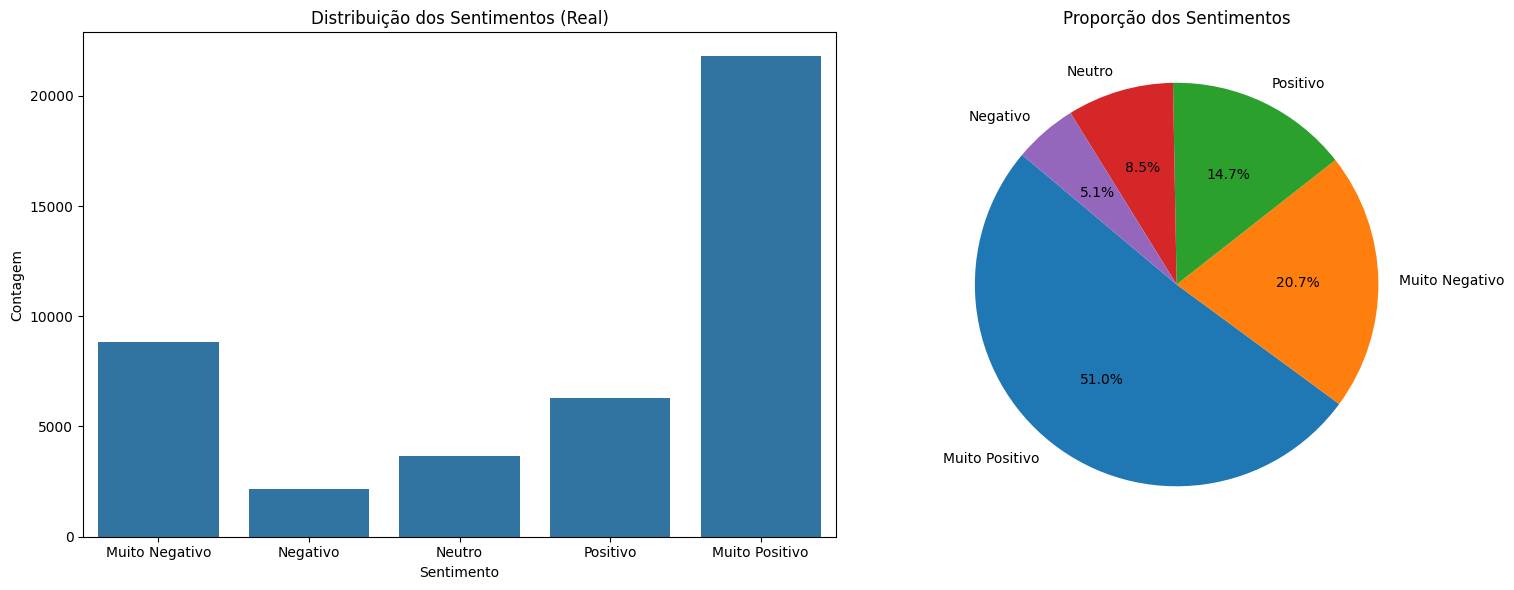

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    x='review_label',
    data=avaliacoes,
    order=['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo'],
    ax=axes[0]
)
axes[0].set_title('Distribuição dos Sentimentos (Real)')
axes[0].set_xlabel('Sentimento')
axes[0].set_ylabel('Contagem')

axes[1].pie(
    avaliacoes['review_label'].value_counts(),
    labels=avaliacoes['review_label'].value_counts().index,
    autopct='%1.1f%%',
    startangle=140
)
axes[1].set_title('Proporção dos Sentimentos')

plt.tight_layout()
plt.show()

## **Exportando o conjunto de dados**

Após o processo de limpeza e tratamento dos dados, o conjunto de avaliações pode ser exportado para o formato **Parquet**, que oferece armazenamento eficiente e melhor desempenho para leitura e escrita de grandes volumes de dados.


In [18]:
# avaliacoes.to_parquet("avaliacoes.parquet", index=False)